Created on 21/07/2026

This script is used to extract and check profiles from multiple sources.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Data from GME (prices), ARSTool (PV and loads), and Swiss grid (FCR remuneration rates) 

In [2]:
if False:
    #------------------------------------------------------------------------------------------------
    # PROFILES
    #------------------------------------------------------------------------------------------------

    # Reading the Excel files
    C_ele_original = pd.read_excel(r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\GME_20240101_20241231_MGP_PrezziZonali_CSUD.xlsx", decimal=',')
    # print(C_ele_original)
    Pl_Ppv_Pwt_original = pd.read_excel(r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\Dati ENEA.xlsx")
    # print(Pl_Ppv_Pwt_original)


    # Extraction of useful profiles
    C_ele_full = C_ele_original['€/MWh'].tolist()               # zonal price (CSUD 2024) [€/MWh], from 01/01/24 to 31/12/24 (leap year, 366 days)
    C_ele = np.array(C_ele_full[:1416] + C_ele_full[1440:])     # removing 29th Feb data to have 365 days (8760 hours) and turning into ndarray
    # C_ele = np.append(C_ele, C_ele[0])                        # make the array go from 0 to 8760 (8761 values)

    C_ele_sell = C_ele / 2

    Pl_comm_to_arrange = Pl_Ppv_Pwt_original['Commerciale'].tolist()            # commercial load profile [p.u.], from 16/10/20 to 15/10/21
    Pl_comm = np.array(Pl_comm_to_arrange[1848:] + Pl_comm_to_arrange[:1848])   # rearranged data from 01/01/21 to 15/10/21 and then from 16/10/20 to 31/12/20

    Pl_ind_to_arrange = Pl_Ppv_Pwt_original['Industriale'].tolist()             # industrial load profile [p.u.], from 16/10/20 to 15/10/21
    Pl_ind = np.array(Pl_ind_to_arrange[1848:] + Pl_ind_to_arrange[:1848])

    Pl_resid_to_arrange = Pl_Ppv_Pwt_original['Residenziale'].tolist()          # residential load profile [p.u.], from 16/10/20 to 15/10/21
    Pl_resid = np.array(Pl_resid_to_arrange[1848:] + Pl_resid_to_arrange[:1848])

    Ppv_to_arrange = Pl_Ppv_Pwt_original['PV'].tolist()         # PV generation profile [??], from 16/10/20 to 15/10/21
    P_pv = np.array(Ppv_to_arrange[1848:] + Ppv_to_arrange[:1848])

    Pwt_to_arrange = Pl_Ppv_Pwt_original['Wind'].tolist()       # WT generation profile [??], from 16/10/20 to 15/10/21
    P_wt = np.array(Pwt_to_arrange[1848:] + Pwt_to_arrange[:1848])


    # Reading the PARQUET file containing the FCR remuneration rate data
    FCR_data_path = r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\market_price_measurement_FCR-cap_CH_2022.parquet"
    C_FCR_original = pd.read_parquet(FCR_data_path, engine="fastparquet")
    # print(C_FCR_original)

    # Exporting the dataframe into an Excel file to check the data
    # C_FCR_original.to_excel('market_price_measurement_FCR-cap_CH_2022.xlsx', sheet_name='Data Export', index=False)

    # Extracting specific columns (max, average, min data)
    C_FCR_fullmax = C_FCR_original['max'].tolist()
    C_FCR_fullavg = C_FCR_original['avg'].tolist()
    # C_FCR_fullmin = C_FCR_original['min'].tolist()

    # Selecting only one year (2024) and removing the 29th Feb data to have 365 days (8760 / 4 values)
    C_FCR_max4h = np.array(C_FCR_fullmax[4380:4734] + C_FCR_fullmax[4740:])    # FCR maximum remuneration rates [€/MWh], from 01/01/24 to 31/12/24 (29/02/24 excluded)
    C_FCR_avg4h = np.array(C_FCR_fullavg[4380:4734] + C_FCR_fullavg[4740:])    # FCR maximum remuneration rates [€/MWh], from 01/01/24 to 31/12/24 (29/02/24 excluded)
    # C_FCR_min = np.array(C_FCR_fullmin[4380:4734] + C_FCR_fullmin[4740:])    # FCR maximum remuneration rates [€/MWh], from 01/01/24 to 31/12/24 (29/02/24 excluded)

    # Repeating the data to have 1-hour intervals instead of 4-hours ones 
    C_FCR_max = np.zeros(8760)
    C_FCR_avg = np.zeros(8760)
    for t in range(len(C_FCR_max4h)):
        for i in range(4):
            C_FCR_max[4*t + i] = C_FCR_max4h[t]
            C_FCR_avg[4*t + i] = C_FCR_avg4h[t]


    # Checking the data -----------------------------------------------------------------------------------
    time = np.arange(0, 8760)

    # Plot settings
    plt.rc('figure', figsize=(20, 20))
    plt.rc('font', family='monospace', weight='bold', size=11)
    plt.rc('axes', labelsize=11, titlesize=14)
    plt.rc('legend', fontsize=11)
    plt.rc('xtick', labelsize=10)
    plt.rc('ytick', labelsize=10)
    plt.rcParams['axes.grid'] = True
    plt.rcParams['lines.linewidth'] = 2

    # """
    # Plots
    fig, axs = plt.subplots(8, 1, layout='constrained')
    axs[0].plot(time, C_ele, color='blue')
    axs[0].set_xlabel('x label')
    axs[0].set_ylabel('y label')
    axs[0].set_title("Electricity Price [€/MWh]")
    axs[0].legend()

    axs[1].plot(time, Pl_comm)
    axs[1].set_title("Commercial load [p.u.]")
    axs[2].plot(time, Pl_ind)
    axs[2].set_title("Industrial load [p.u.]")
    axs[3].plot(time, Pl_resid)
    axs[3].set_title("Residential load [p.u.]")
    axs[4].plot(time, P_pv)
    axs[4].set_title("PV generation [??]")
    axs[5].plot(time, P_wt)
    axs[5].set_title("WT generation [??]")
    axs[6].plot(time, C_FCR_max)
    axs[6].set_title("FCR remuneration rates (max) [€/MWh]")
    axs[7].plot(time, C_FCR_avg)
    axs[7].set_title("FCR remuneration rates (avg) [€/MWh]")
    # """


    # Profiles adjustments based on rated powers
    Ppv_rtd = 3
    Pl_comm_rtd = 1
    Pl_ind_rtd = 1
    Pl_resid_rtd = 1

    Pl_comm = Pl_comm * Pl_comm_rtd         # Commercial load profile [MW]
    Pl_ind = Pl_ind * Pl_ind_rtd            # Industrial load profile [MW]
    Pl_resid = Pl_resid * Pl_resid_rtd      # Residential load profile [MW]
    P_load = Pl_ind + Pl_comm              # load profile used in the optimization problem [MW]
    P_pv = (P_pv / 2) * Ppv_rtd             # PV generation profile [MW]
    # Pwt = Pwt * Pwt_rtd                   # WT generation profile [MW]

    # Scaling the FCR remuneration rates
    multiplier_FCR = 1
    C_FCR = C_FCR_avg * multiplier_FCR

    # """
    # Checking the data after adjustments
    fig, axs = plt.subplots(5, 1, layout='constrained')
    axs[0].plot(time, C_ele, color='blue')
    axs[0].set_xlabel('x label')
    axs[0].set_ylabel('y label')
    axs[0].set_title("Electricity Price [€/MWh]")
    axs[0].legend()

    axs[1].plot(time, Pl_comm)
    axs[1].set_title("Commercial load [MW]")
    axs[2].plot(time, Pl_ind)
    axs[2].set_title("Industrial load [MW]")
    axs[3].plot(time, Pl_resid)
    axs[3].set_title("Residential load [MW]")
    axs[4].plot(time, P_pv)
    axs[4].set_title("PV generation [MW]")
    # axs[5].plot(time, P_wt)
    # axs[5].set_title("WT generation")
    # """

#### Data from New Jersey dataset (PV and loads) 

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.00512821 0.03589744 0.11282051 0.16153846 0.18974359
 0.25384615 0.36153846 0.43076923 0.40769231 0.43846154 0.46923077
 0.49487179 0.32820513 0.15128205 0.46153846 0.17692308 0.30769231
 0.16923077 0.52820513 0.63076923 0.71538462 0.74358974 0.7025641
 0.72051282 0.75897436 0.91538462 0.95641026 0.94358974 0.77179487
 0.68461538 0.69230769 0.69230769 0.65384615 0.61794872 0.58717949
 0.53589744 0.50769231 0.45641026 0.4        0.33846154 0.08717949
 0.18974359 0.08205128 0.05128205 0.05897436 0.01794872 0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.  

Text(0.5, 1.0, 'PV generation (Dt = 1 h) [kW]')

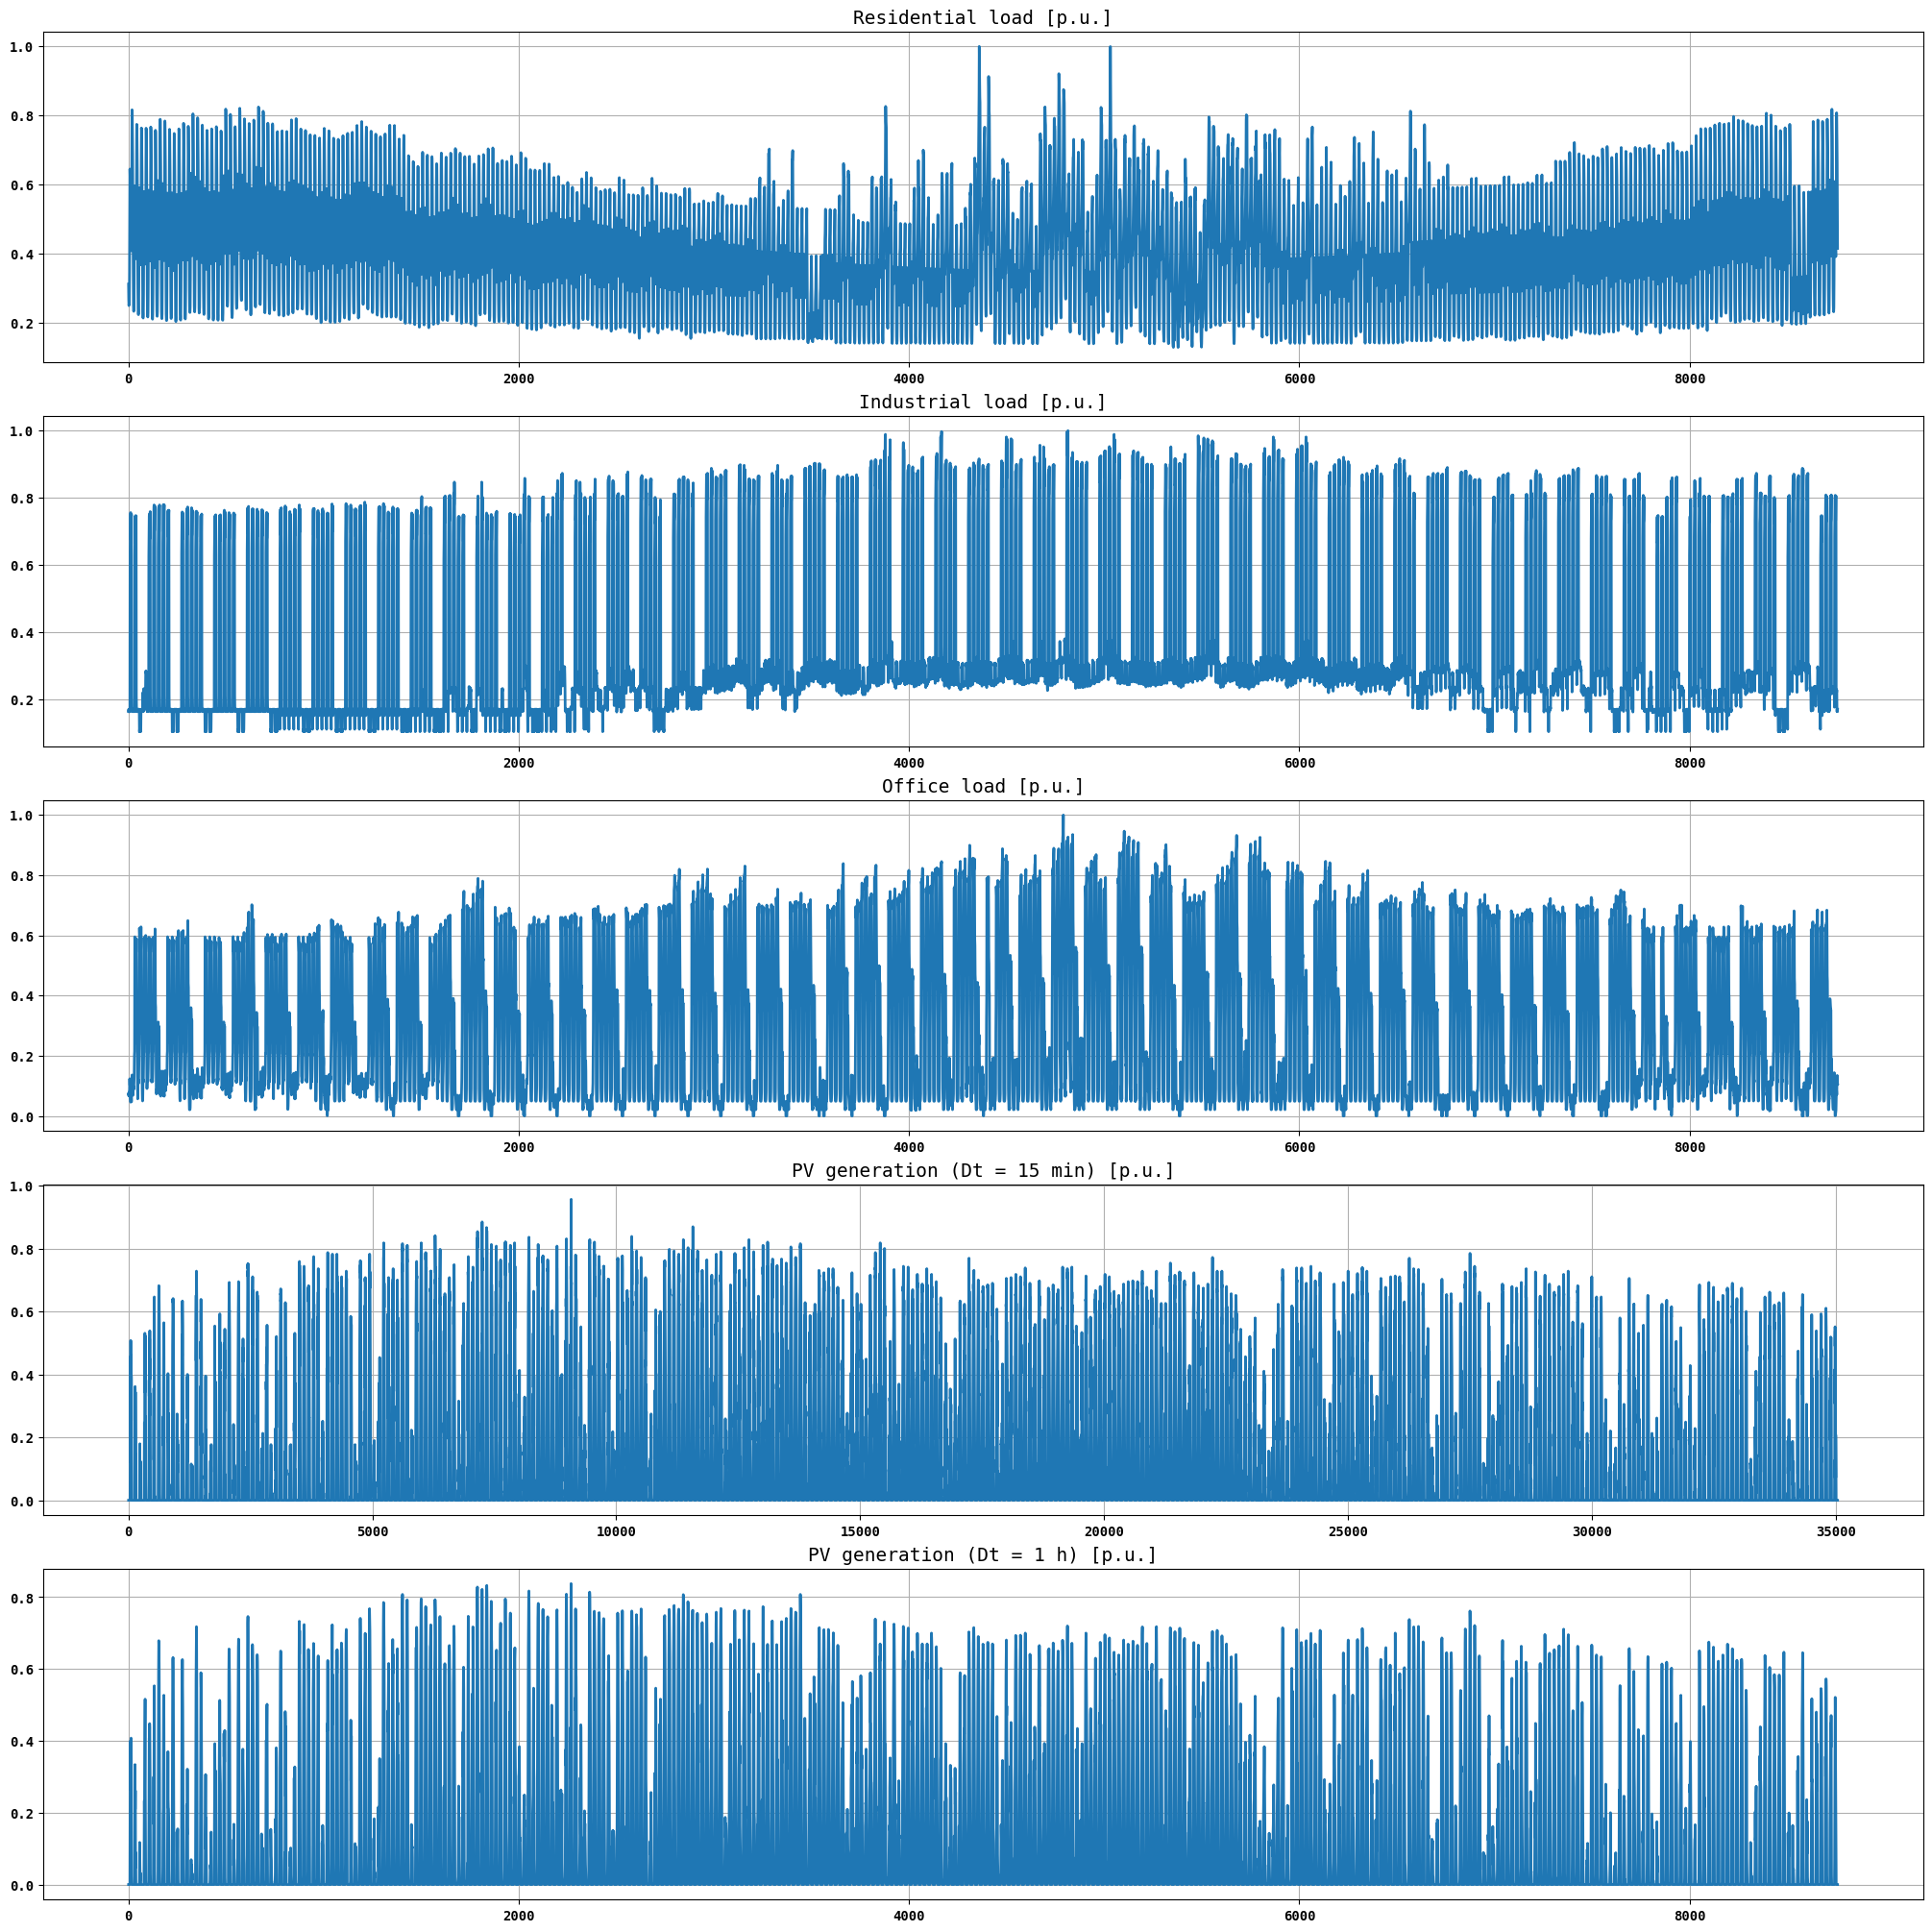

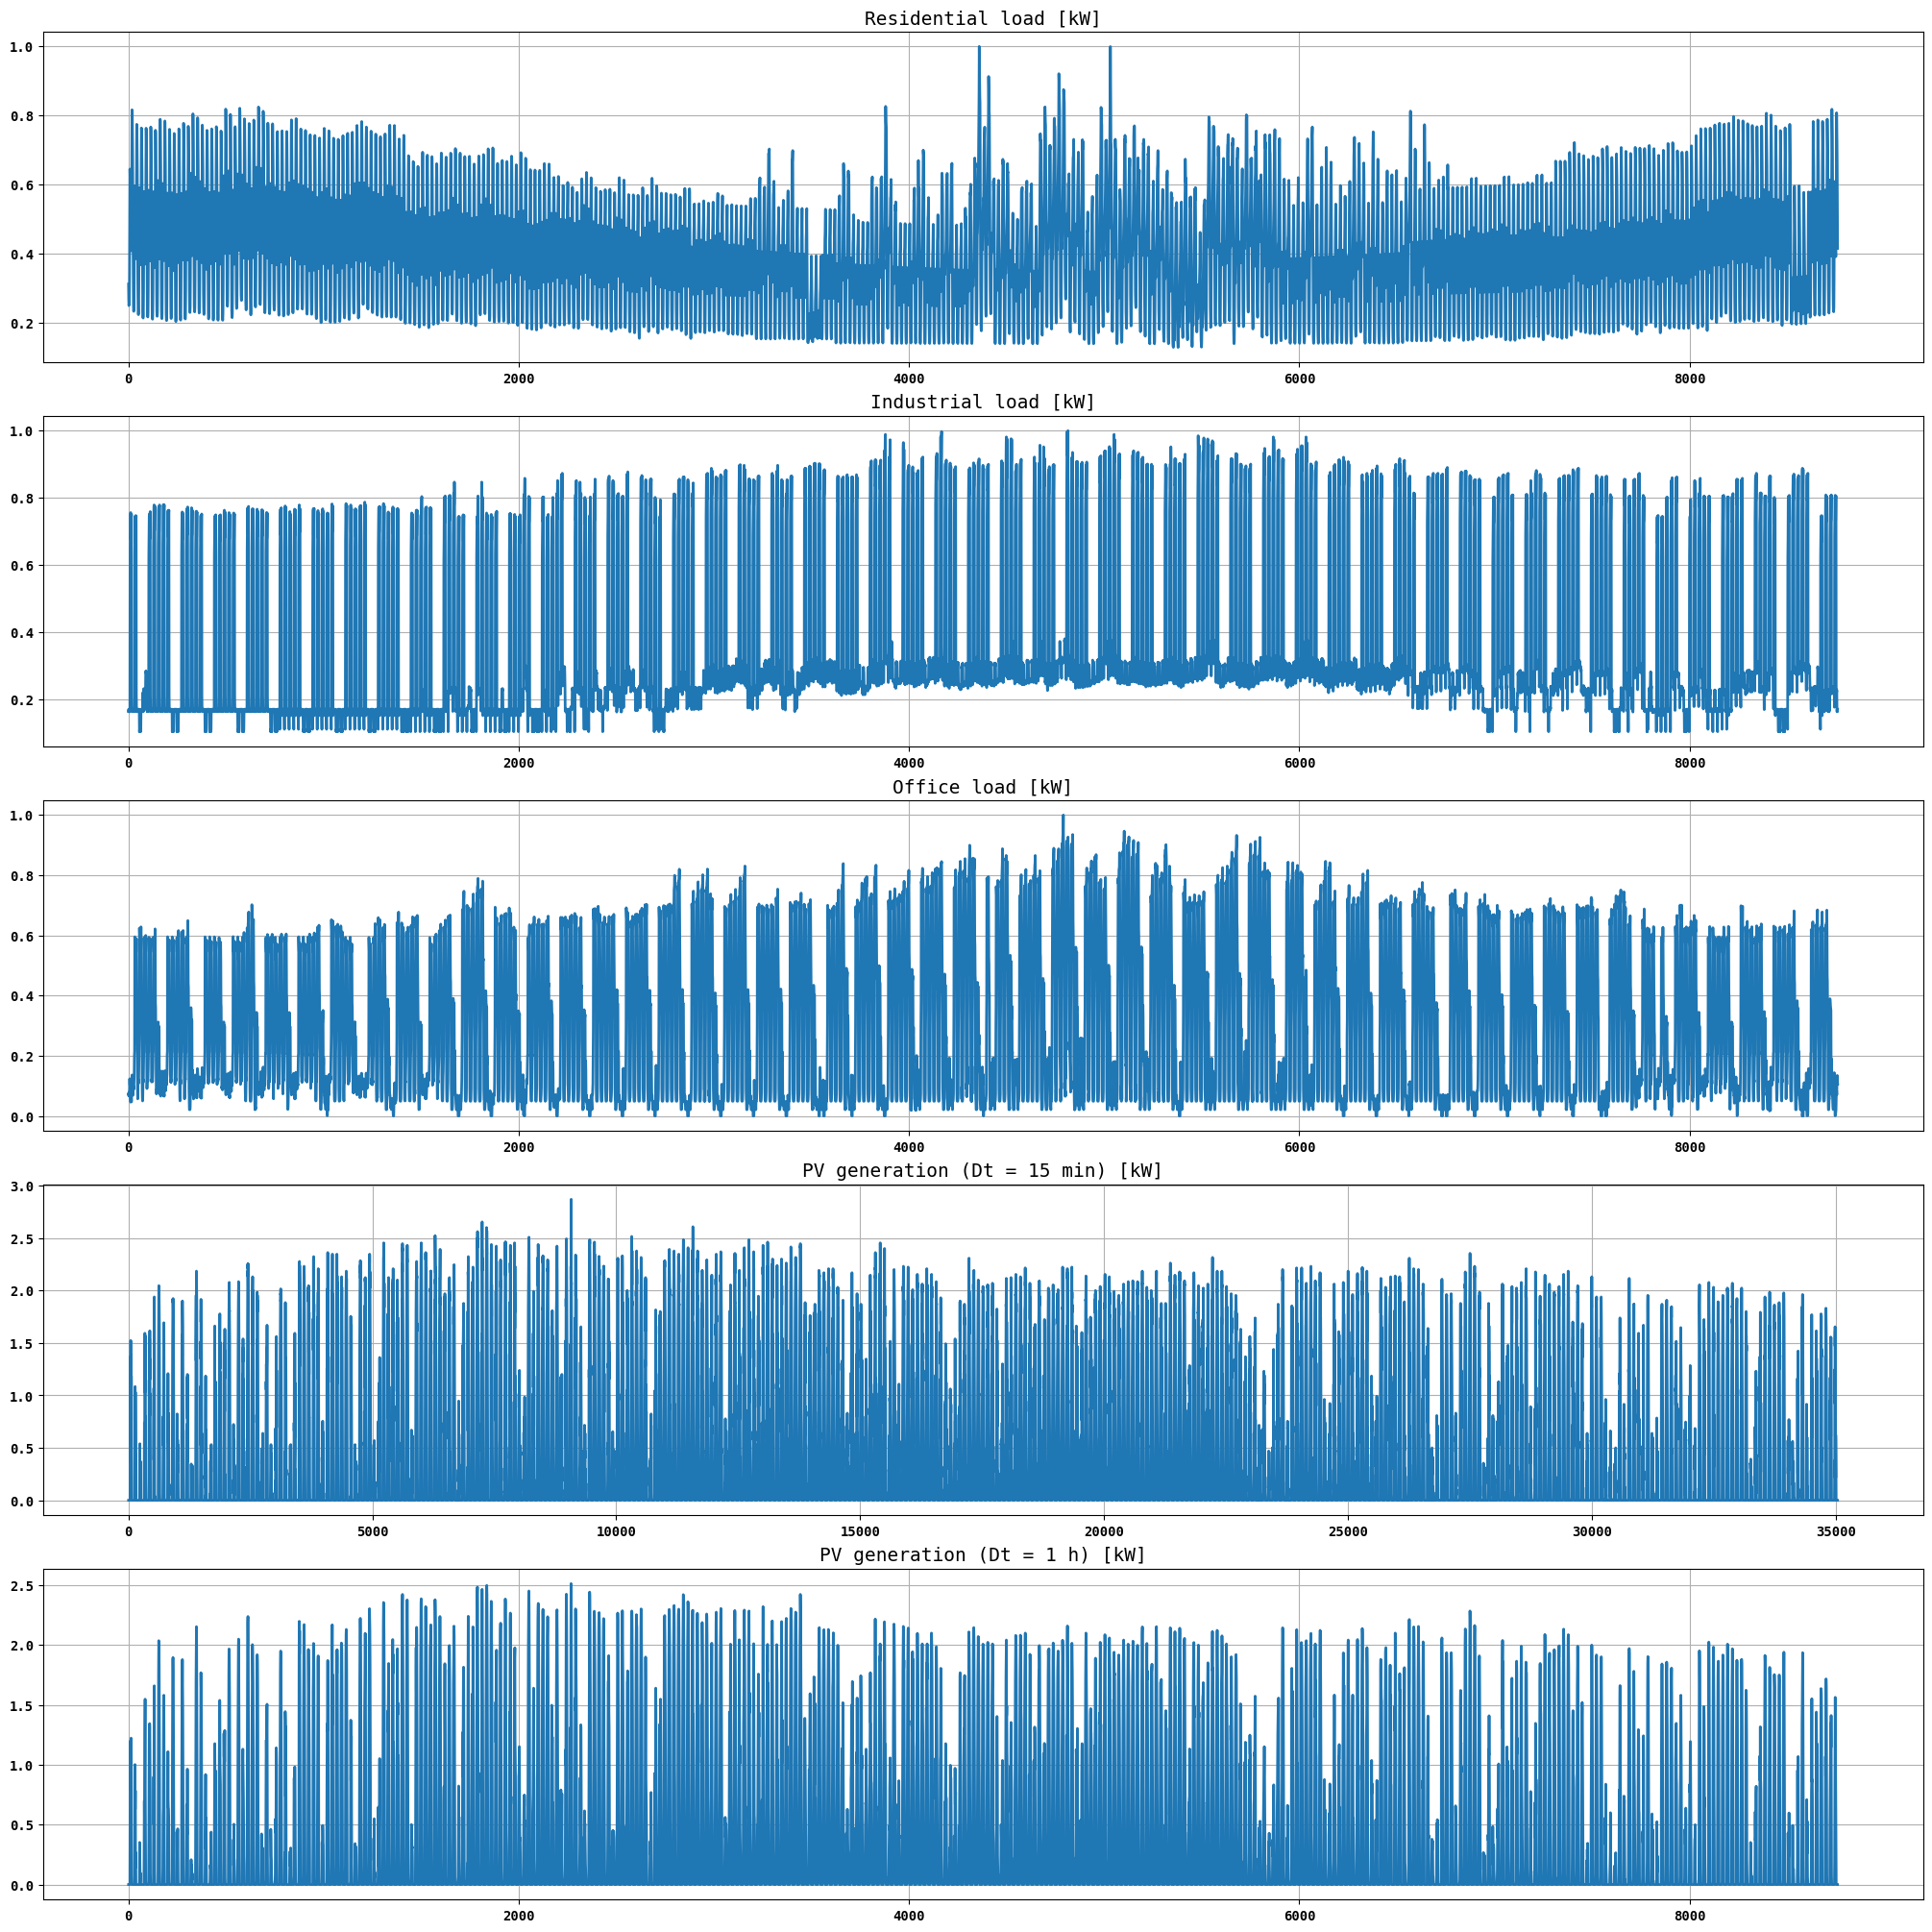

In [ ]:
# Reading the Excel files
Pl_resid_original = pd.read_csv(r"C:\Users\massi\Università_user\Dottorato\Materiale\Dati\Carichi\New Jersey Dataset on Hourly Load Profiles for 24 Facilities (8760 hours)\Residential.csv")
Pl_ind_original = pd.read_csv(r"C:\Users\massi\Università_user\Dottorato\Materiale\Dati\Carichi\New Jersey Dataset on Hourly Load Profiles for 24 Facilities (8760 hours)\Industrial-General Manufacturer.csv")
Pl_off_original = pd.read_csv(r"C:\Users\massi\Università_user\Dottorato\Materiale\Dati\Carichi\New Jersey Dataset on Hourly Load Profiles for 24 Facilities (8760 hours)\Reference-Office.csv")

Ppv_df = pd.read_csv(r"C:\Users\massi\Università_user\Dottorato\Materiale\Dati\Generazione\New Jersey PV generation data 2026 (Actual, DA, HA4)\Actual_39.35_-75.25_2006_UPV_13MW_5_Min.csv")


# Extraction of useful profiles
Pl_resid_list = Pl_resid_original['Power [kW]'].tolist()    # residential load profile [kW], from 01/01 to 31/12 (year unspecified), 1-hour steps
# print(Pl_resid_list)
Pl_ind_list = Pl_ind_original['Power [kW]'].tolist()        # industrial (general manufacturer) load profile [kW], from 01/01 to 31/12 (year unspecified), 1 hour steps 
Pl_off_list = Pl_off_original['Power [kW]'].tolist()        # office load profile [kW], from 01/01 to 31/12 (year unspecified), 1 hour steps

Ppv_original = Ppv_df['Power(MW)'].tolist()                 # PV generation profile from a 13 MW plant [MW], from 01/01/06 to 31/12/06, 5-min steps
Ppv_15min = np.zeros(8760 * 4)                              # PV generation profile 15-min steps
Ppv_1h = np.zeros(8760)                                     # PV generation profile 1-hour steps
for t in range(len(Ppv_15min)):
    Ppv_15min[t] = np.mean(Ppv_original[t*3: (t+1)*3])
for t in range(len(Ppv_1h)):
    Ppv_1h[t] = np.mean(Ppv_original[t*12: (t+1)*12])


# Normalize the data based on peak power (loads) or rated power (PV)
peak_resid = np.max(Pl_resid_list)                            
Pl_resid_pu = Pl_resid_list / peak_resid

peak_ind = np.max(Pl_ind_list)
Pl_ind_pu = Pl_ind_list / peak_ind

peak_off = np.max(Pl_off_list)
Pl_off_pu = Pl_off_list / peak_off

Ppv_rtd_original = 13        # rated PV power of the original data PV plant
Ppv_15min_pu = Ppv_15min / Ppv_rtd_original
Ppv_1h_pu = Ppv_1h / Ppv_rtd_original
# NOTE: il profilo in p.u. raggiunge al massimo 0.8378

# print(Pl_resid_pu)
# print(peak_resid)
# print(Pl_ind_pu)
# print(peak_ind)
# print(Pl_off_pu)
# print(peak_off)


# Scale the data based on the sizes chosen for the case study
Ppv_rtd = 3
Pl_resid_rtd = 1
Pl_ind_rtd = 1
Pl_off_rtd = 1

Pl_resid = Pl_resid_pu * Pl_resid_rtd    # yearly residential load profile [kW]
Pl_ind = Pl_ind_pu * Pl_ind_rtd          # yearly industrial load profile [kW]
Pl_off = Pl_off_pu * Pl_off_rtd          # yearly office load profile [kW]
Ppv_15min = Ppv_15min_pu * Ppv_rtd       # yearly PV generation profile, 15-min steps [kW]
Ppv_1h = Ppv_1h_pu * Ppv_rtd             # yearly PV generation profile, 1-hour steps [kW]

day = 94    # 04/04: è il giorno che contiene il picco di produzione dell'impianto
print(Ppv_15min_pu[day * 96 : (day + 1) * 96])
# day = 91    # 01/04: è il giorno che contiene il picco di produzione dell'impianto
# print(Ppv_15min_pu[day * 96 : (day + 1) * 96])
# day = 90    # 31/03: è il giorno che contiene il picco di produzione dell'impianto
# print(Ppv_15min_pu[day * 96 : (day + 1) * 96])



# Checking the data -----------------------------------------------------------------------------------
time = np.arange(0, 8760)
time_15min = np.arange(0, 8760 * 4)

# Plot settings
plt.rc('figure', figsize=(20, 20))
plt.rc('font', family='monospace', weight='bold', size=11)
plt.rc('axes', labelsize=11, titlesize=14)
plt.rc('legend', fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rcParams['axes.grid'] = True
plt.rcParams['lines.linewidth'] = 2

# Plots --------
# Original data
fig, axs = plt.subplots(5, 1, layout='constrained')
axs[0].plot(time, Pl_resid_pu)
axs[0].set_title("Residential load [p.u.]")
axs[1].plot(time, Pl_ind_pu)
axs[1].set_title("Industrial load [p.u.]")
axs[2].plot(time, Pl_off_pu)
axs[2].set_title("Office load [p.u.]")
axs[3].plot(time_15min, Ppv_15min_pu)
axs[3].set_title("PV generation (Dt = 15 min) [p.u.]")
axs[4].plot(time, Ppv_1h_pu)
axs[4].set_title("PV generation (Dt = 1 h) [p.u.]")

# Scaled data
fig, axs = plt.subplots(5, 1, layout='constrained')
axs[0].plot(time, Pl_resid)
axs[0].set_title("Residential load [kW]")
axs[1].plot(time, Pl_ind)
axs[1].set_title("Industrial load [kW]")
axs[2].plot(time, Pl_off)
axs[2].set_title("Office load [kW]")
axs[3].plot(time_15min, Ppv_15min)
axs[3].set_title("PV generation (Dt = 15 min) [kW]")
axs[4].plot(time, Ppv_1h)
axs[4].set_title("PV generation (Dt = 1 h) [kW]")
